# Wikipedia EN - Feature Extraction and Full Analysis
### IS-618 - University of Mannheim - Marmee Pandya

Loads already-collected data. No re-collection.

**Required files:** final_contested_en.json, final_stable_en.json, final_pairs_en.json, final_features_en.csv

## 0. Setup

In [3]:
import json, os, re, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import resample
from scipy.stats import wilcoxon
from collections import Counter

# for f in ['final_contested_en.json','final_stable_en.json','final_pairs_en.json','final_features_en.csv']:
#     print(f'  {"OK" if os.path.exists(f) else "MISSING"} {f}')

## 1. Load Data

In [4]:
text_map = {}
for fname in ['final_contested_en.json','final_stable_en.json']:
    with open(fname, encoding='utf-8') as f:
        arts = json.load(f)
    for a in arts:
        text_map[a['title']] = a.get('clean_text','')
    print(f'  Loaded {len(arts)} texts from {fname}')

with open('final_pairs_en.json', encoding='utf-8') as f:
    pairs = json.load(f)
print(f'  Loaded {len(pairs)} matched pairs')

df = pd.read_csv('final_features_en.csv')
print(f'  Feature matrix: {df.shape[0]} articles x {df.shape[1]} columns')
print(f'  Contested: {(df.label==0).sum()} | Stable: {(df.label==1).sum()}')

  Loaded 200 texts from final_contested_en.json
  Loaded 400 texts from final_stable_en.json
  Loaded 161 matched pairs
  Feature matrix: 330 articles x 20 columns
  Contested: 161 | Stable: 169


## 2. Add New Features (Partisan Attribution + Causal Connectives)
Skips if already computed.

In [5]:
PARTISAN_PATTERNS = [
    r'critics?\s+(say|said|argue|argued|claim|claimed)',
    r'opponents?\s+(say|claim|argue|suggest)',
    r'supporters?\s+(say|claim|argue|suggest)',
    r'proponents?\s+(say|claim|argue|suggest)',
    r'(those who oppose|those who support)',
    r'(conservatives?|liberals?|left|right)\s+(say|claim|argue)',
]
CAUSAL_WORDS = [
    'because','therefore','thus','hence','consequently',
    'as a result','due to','owing to','since','leads to',
    'caused by','results in','for this reason','accordingly',
]

def partisan_density(text):
    n = max(len(text.split()),1)
    count = sum(len(re.findall(p, text.lower())) for p in PARTISAN_PATTERNS)
    return round(count/n*1000, 4)

def causal_density(text):
    n = max(len(text.split()),1)
    count = sum(text.lower().count(w) for w in CAUSAL_WORDS)
    return round(count/n*1000, 4)

if 'partisan_density' not in df.columns:
    df['partisan_density'] = df['title'].map(lambda t: partisan_density(text_map.get(t,'')) if text_map.get(t,'') else np.nan)
    print('Computed partisan_density')
if 'causal_density' not in df.columns:
    df['causal_density'] = df['title'].map(lambda t: causal_density(text_map.get(t,'')) if text_map.get(t,'') else np.nan)
    print('Computed causal_density')

df.to_csv('final_features_en.csv', index=False)
print(f'Saved: final_features_en.csv ({df.shape[1]} columns)')

Saved: final_features_en.csv (20 columns)


## 3. Feature Overview

In [6]:
LAYER1 = ['hedging_density','partisan_density']
LAYER2 = ['def_ratio','causal_density']
STRUCT = ['citation_count','section_count']
BEHAV  = ['unique_editors','recency_ratio','revert_count','talk_words','talk_editors']
ALL_FEATURES = LAYER1 + LAYER2 + STRUCT + BEHAV

LABELS = {
    'hedging_density':'Hedging Density','partisan_density':'Partisan Attribution',
    'def_ratio':'Definition Ratio','causal_density':'Causal Connectives',
    'citation_count':'Citation Count','section_count':'Section Count',
    'unique_editors':'Unique Editors','age_days':'Article Age',
    'recency_ratio':'Edit Recency Ratio','revert_count':'Revert Count',
    'talk_words':'Talk Word Count','talk_editors':'Talk Editors',
}
LAYER_MAP = {
    'hedging_density':'L1','partisan_density':'L1',
    'def_ratio':'L2','causal_density':'L2',
    'citation_count':'Struct','section_count':'Struct',
    'unique_editors':'Behav','recency_ratio':'Behav',
    'revert_count':'Behav','talk_words':'Behav','talk_editors':'Behav',
}

avail = [f for f in ALL_FEATURES if f in df.columns]
c_df  = df[df.label==0]
s_df  = df[df.label==1]

print(f'{"Feature":<25} {"Contested":>12} {"Stable":>12} {"Diff%":>8}  Layer')
print('-'*72)
for col in avail:
    cm_ = c_df[col].mean()
    sm_ = s_df[col].mean()
    diff = (cm_-sm_)/(sm_+1e-9)*100
    print(f'{LABELS.get(col,col):<25} {cm_:>12.4f} {sm_:>12.4f} {"up" if diff>0 else "dn"}{abs(diff):>6.1f}%  {LAYER_MAP.get(col,"")}')


Feature                      Contested       Stable    Diff%  Layer
------------------------------------------------------------------------
Hedging Density                 0.8596       0.2689 up 219.7%  L1
Partisan Attribution            0.0173       0.0000 up1726583850.9%  L1
Definition Ratio                0.0509       0.0367 up  38.8%  L2
Causal Connectives              2.1715       1.7871 up  21.5%  L2
Citation Count                 55.3292      60.9527 dn   9.2%  Struct
Section Count                  13.9130      11.0888 up  25.5%  Struct
Unique Editors                121.7267      95.5621 up  27.4%  Behav
Edit Recency Ratio              0.0339       0.0359 dn   5.6%  Behav
Revert Count                    0.4845       0.3432 up  41.2%  Behav
Talk Word Count              1596.3975     659.2367 up 142.2%  Behav
Talk Editors                   15.2981      16.4142 dn   6.8%  Behav


## 4. Wilcoxon Signed-Rank Tests (Primary)

In [7]:
diff_records = []
for p in pairs:
    c_row = df[df.title==p['contested']['title']]
    s_row = df[df.title==p['stable']['title']]
    if c_row.empty or s_row.empty: continue
    c_row, s_row = c_row.iloc[0], s_row.iloc[0]
    record = {f'diff_{feat}': c_row.get(feat,np.nan)-s_row.get(feat,np.nan) for feat in avail}
    diff_records.append(record)

diff_df = pd.DataFrame(diff_records)
print(f'Pair differences: {len(diff_df)} pairs\n')
print(f'{"Feature":<25} {"Mean diff":>10} {"C>S %":>8} {"p-value":>10}  Sig?  Layer')
print('-'*70)

wilcox_results = []
for feat in avail:
    col  = f'diff_{feat}'
    if col not in diff_df: continue
    vals = diff_df[col].dropna()
    if len(vals)<5: continue
    mean = vals.mean()
    pct  = (vals>0).mean()*100
    try:
        _,p = wilcoxon(vals)
        sig = 'YES' if p<0.05 else ('~' if p<0.10 else 'no')
        print(f'{LABELS.get(feat,feat):<25} {mean:>10.4f} {pct:>7.1f}% {p:>10.4f}  {sig:<4}  {LAYER_MAP.get(feat,"")}')
        wilcox_results.append({'feature':feat,'p':p,'mean_diff':mean,'pct_c_higher':pct,'sig':p<0.05})
    except: pass

print('\nYES=p<0.05  ~=p<0.10  no=not significant')

Pair differences: 161 pairs

Feature                    Mean diff    C>S %    p-value  Sig?  Layer
----------------------------------------------------------------------
Hedging Density               0.5869    52.8%     0.0000  YES   L1
Partisan Attribution          0.0173     3.1%     0.0431  YES   L1
Definition Ratio              0.0147    65.2%     0.0001  YES   L2
Causal Connectives            0.3462    50.9%     0.1381  no    L2
Citation Count               -6.6398    43.5%     0.0724  ~     Struct
Section Count                 2.7143    65.2%     0.0000  YES   Struct
Unique Editors               25.0807    72.0%     0.0000  YES   Behav
Edit Recency Ratio           -0.0015    54.7%     0.0290  YES   Behav
Revert Count                  0.1366    17.4%     0.3751  no    Behav
Talk Word Count             927.7267    63.4%     0.0000  YES   Behav
Talk Editors                 -1.1491    39.1%     0.1067  no    Behav

YES=p<0.05  ~=p<0.10  no=not significant


## 5. Feature Distribution Plots

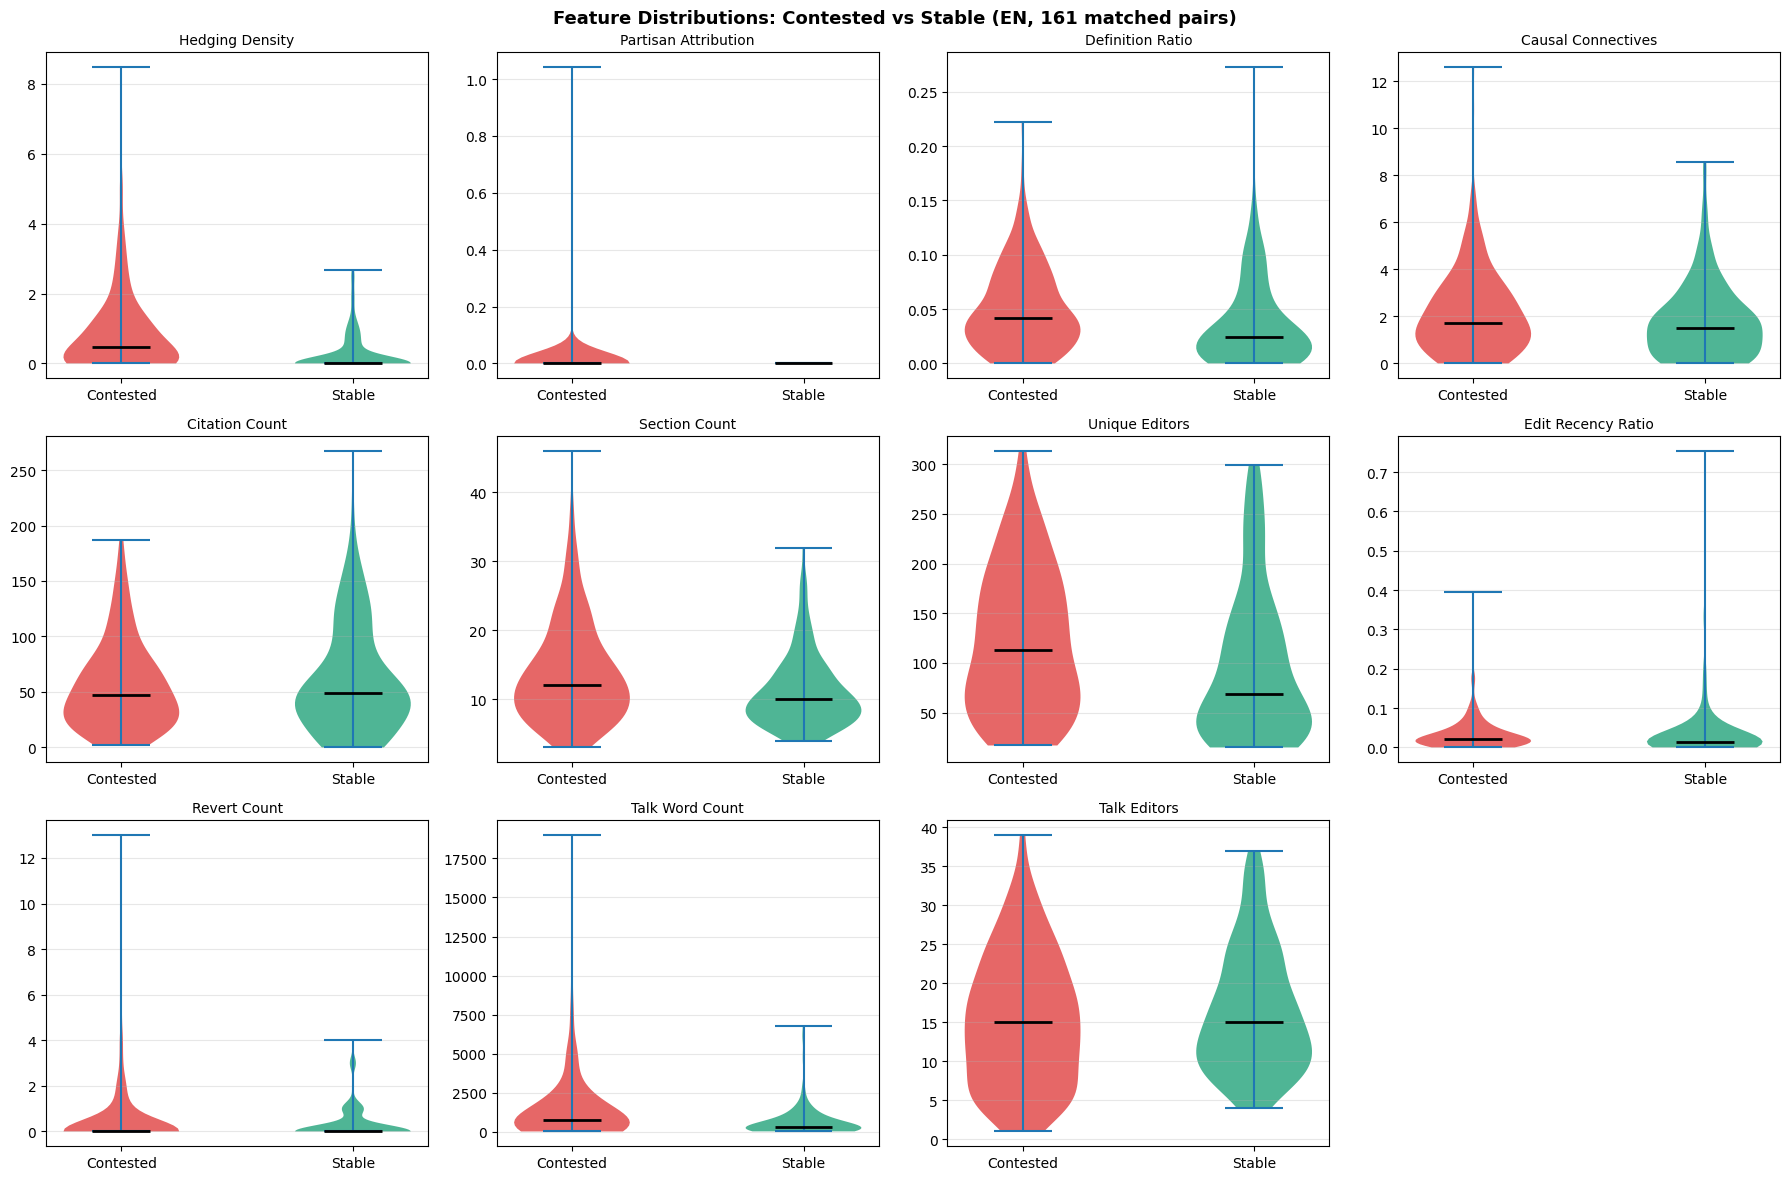

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18,12))
fig.suptitle('Feature Distributions: Contested vs Stable (EN, 161 matched pairs)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(avail):
    if i >= len(axes): break
    ax = axes[i]
    parts = ax.violinplot([c_df[col].dropna().values, s_df[col].dropna().values], positions=[0,1], showmedians=True)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(['#DC2626','#059669'][j])
        pc.set_alpha(0.7)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Contested','Stable'])
    ax.set_title(LABELS.get(col,col), fontsize=10)
    ax.grid(axis='y', alpha=0.3)

for j in range(len(avail), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('final_feature_distributions_en.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Logistic Regression

In [9]:
df_topic  = pd.get_dummies(df['topic'], prefix='topic', drop_first=True)
df_model  = pd.concat([df.reset_index(drop=True), df_topic.reset_index(drop=True)], axis=1)
topic_cols = list(df_topic.columns)

cv_  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
m_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

feature_sets = {
    'Linguistic only (L1+L2)': [f for f in LAYER1+LAYER2 if f in df_model.columns],
    'Structural only':          [f for f in STRUCT if f in df_model.columns],
    'Behavioral only':          [f for f in BEHAV  if f in df_model.columns],
    'All features':             [f for f in ALL_FEATURES if f in df_model.columns],
    'All + topic control':      [f for f in ALL_FEATURES if f in df_model.columns]+topic_cols,
}

print(f'{"Feature set":<30} {"F1":>8} {"Accuracy":>10} {"vs baseline":>12}')
print('-'*62)
results_f1 = {}

for name, feats in feature_sets.items():
    avail_f = [f for f in feats if f in df_model.columns]
    if len(avail_f)<2: continue
    d  = df_model[avail_f+['label']].dropna()
    X  = StandardScaler().fit_transform(d[avail_f].values)
    y  = d['label'].values
    if len(set(y))<2: continue
    f1s  = cross_val_score(m_lr, X, y, cv=cv_, scoring='f1_macro')
    accs = cross_val_score(m_lr, X, y, cv=cv_, scoring='accuracy')
    base = max(y.mean(), 1-y.mean())
    results_f1[name] = f1s.mean()
    print(f'{name:<30} {f1s.mean():>8.3f} {accs.mean():>10.3f} {accs.mean()-base:>+12.3f}')

Feature set                          F1   Accuracy  vs baseline
--------------------------------------------------------------
Linguistic only (L1+L2)           0.642      0.645       +0.133
Structural only                   0.607      0.609       +0.097
Behavioral only                   0.723      0.724       +0.212
All features                      0.708      0.709       +0.197
All + topic control               0.690      0.691       +0.179


## 7. Coefficient Chart

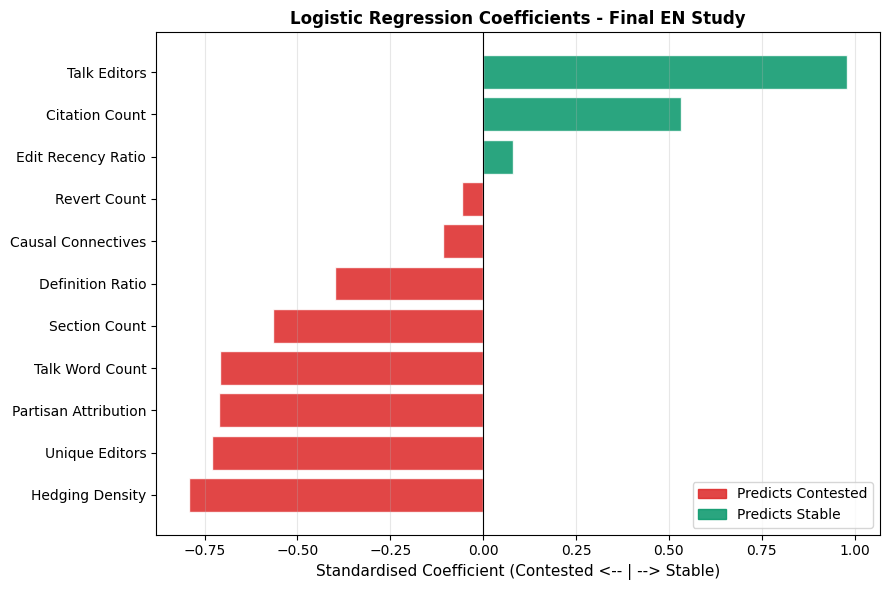

In [10]:
best_feats = [f for f in ALL_FEATURES if f in df_model.columns]
d_full = df_model[best_feats+['label']].dropna()
X_full = StandardScaler().fit_transform(d_full[best_feats].values)
y_full = d_full['label'].values
m_lr.fit(X_full, y_full)

coef_df = pd.DataFrame({
    'feature':     [LABELS.get(f,f) for f in best_feats],
    'coefficient': m_lr.coef_[0],
}).sort_values('coefficient')

colors = ['#DC2626' if c<0 else '#059669' for c in coef_df['coefficient']]
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient (Contested <-- | --> Stable)', fontsize=11)
ax.set_title('Logistic Regression Coefficients - Final EN Study', fontsize=12, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#DC2626', alpha=0.85, label='Predicts Contested'),
    mpatches.Patch(color='#059669', alpha=0.85, label='Predicts Stable'),
], loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('final_coefficients_en.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Bootstrap Confidence Intervals

In [11]:
print('Bootstrap 95% CI (500 resamples)\n')
print(f'{"Feature":<25} {"Coef":>8} {"95% CI":>22}  Stable?')
print('-'*65)

coef_boot = []
for _ in range(500):
    X_b, y_b = resample(X_full, y_full, random_state=None)
    if len(set(y_b))<2: continue
    m_b = LogisticRegression(class_weight='balanced', max_iter=1000)
    m_b.fit(X_b, y_b)
    coef_boot.append(m_b.coef_[0])

coef_arr = np.array(coef_boot)
stable_features, unstable_features = [], []

for i, feat in enumerate(best_feats):
    lo = np.percentile(coef_arr[:,i], 2.5)
    hi = np.percentile(coef_arr[:,i], 97.5)
    c  = m_lr.coef_[0][i]
    ok = 'YES' if (lo>0 or hi<0) else 'unstable'
    print(f'  {LABELS.get(feat,feat):<23} {c:>+8.3f} [{lo:>+7.3f}, {hi:>+7.3f}]  {ok}')
    (stable_features if ok=='YES' else unstable_features).append(feat)

print(f'\nStable   : {[LABELS.get(f,f) for f in stable_features]}')
print(f'Unstable : {[LABELS.get(f,f) for f in unstable_features]}')
print('\nYES = CI does not cross zero = reliable direction')

Bootstrap 95% CI (500 resamples)

Feature                       Coef                 95% CI  Stable?
-----------------------------------------------------------------
  Hedging Density           -0.792 [ -1.237,  -0.488]  YES
  Partisan Attribution      -0.711 [ -1.045,  -0.191]  YES
  Definition Ratio          -0.400 [ -0.736,  -0.172]  YES
  Causal Connectives        -0.107 [ -0.350,  +0.180]  unstable
  Citation Count            +0.532 [ +0.262,  +0.949]  YES
  Section Count             -0.565 [ -1.002,  -0.258]  YES
  Unique Editors            -0.731 [ -1.220,  -0.365]  YES
  Edit Recency Ratio        +0.082 [ -0.281,  +0.395]  unstable
  Revert Count              -0.057 [ -0.334,  +0.321]  unstable
  Talk Word Count           -0.707 [ -1.586,  -0.215]  YES
  Talk Editors              +0.980 [ +0.584,  +1.521]  YES

Stable   : ['Hedging Density', 'Partisan Attribution', 'Definition Ratio', 'Citation Count', 'Section Count', 'Unique Editors', 'Talk Word Count', 'Talk Editors']
Unsta

## 9. Error Analysis

In [12]:
print('='*65 + '\nERROR ANALYSIS\n' + '='*65)

d_ea = df_model[best_feats+['label','title','topic']].dropna()
X_ea = StandardScaler().fit_transform(d_ea[best_feats].values)
y_ea = d_ea['label'].values

y_true_all, y_pred_all = [], []
for train_idx, test_idx in StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X_ea, y_ea):
    m_lr.fit(X_ea[train_idx], y_ea[train_idx])
    y_true_all.extend(y_ea[test_idx])
    y_pred_all.extend(m_lr.predict(X_ea[test_idx]))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
cm_ea   = confusion_matrix(y_true_all, y_pred_all)
total   = len(y_true_all)
correct = (y_true_all==y_pred_all).sum()

print(f'\nConfusion Matrix:')
print(f'                      Predicted Contested  Predicted Stable')
print(f'  Actual Contested    {cm_ea[0][0]:>18}  {cm_ea[0][1]:>15}')
print(f'  Actual Stable       {cm_ea[1][0]:>18}  {cm_ea[1][1]:>15}')
print(f'\n  Correct : {correct}/{total} ({100*correct//total}%)')
print(f'  Wrong   : {total-correct}/{total} ({100*(total-correct)//total}%)')
print(f'  False positives: {cm_ea[1][0]} stable called contested')
print(f'  False negatives: {cm_ea[0][1]} contested called stable')
print('\nClassification Report:')
print(classification_report(y_true_all, y_pred_all, target_names=['Contested','Stable']))

m_lr.fit(X_ea, y_ea)
d_ea = d_ea.copy()
d_ea['predicted'] = m_lr.predict(X_ea)

fp_df = d_ea[(d_ea.label==1)&(d_ea.predicted==0)]
fn_df = d_ea[(d_ea.label==0)&(d_ea.predicted==1)]

print(f'\nStable misclassified as Contested ({len(fp_df)}):')
for _, row in fp_df.head(8).iterrows():
    print(f'  - {row["title"][:55]:<55} [{row["topic"]}]')

print(f'\nContested misclassified as Stable ({len(fn_df)}):')
for _, row in fn_df.head(8).iterrows():
    print(f'  - {row["title"][:55]:<55} [{row["topic"]}]')

print('\nPerformance by Topic:')
print(f'{"Topic":<22} {"F1":>6} {"Accuracy":>10} {"n":>5}')
print('-'*48)
for topic in ['politics_history','culture','geography','science']:
    sub = d_ea[d_ea.topic==topic]
    if len(sub)<8: continue
    X_t = StandardScaler().fit_transform(sub[best_feats].values)
    y_t = sub['label'].values
    n_s = min(5,len(y_t)//2)
    if n_s<2: continue
    cv_t = StratifiedKFold(n_splits=n_s, shuffle=True, random_state=42)
    f1_t = cross_val_score(m_lr, X_t, y_t, cv=cv_t, scoring='f1_macro')
    acc_t = cross_val_score(m_lr, X_t, y_t, cv=cv_t, scoring='accuracy')
    print(f'  {topic:<20} {f1_t.mean():>6.3f} {acc_t.mean():>10.3f} {len(sub):>5}')

ERROR ANALYSIS

Confusion Matrix:
                      Predicted Contested  Predicted Stable
  Actual Contested                   114               47
  Actual Stable                       49              120

  Correct : 234/330 (70%)
  Wrong   : 96/330 (29%)
  False positives: 49 stable called contested
  False negatives: 47 contested called stable

Classification Report:
              precision    recall  f1-score   support

   Contested       0.70      0.71      0.70       161
      Stable       0.72      0.71      0.71       169

    accuracy                           0.71       330
   macro avg       0.71      0.71      0.71       330
weighted avg       0.71      0.71      0.71       330


Stable misclassified as Contested (42):
  - Bugesera invasion                                       [geography]
  - Baldwin I of Jerusalem                                  [politics_history]
  - Behemoth (roller coaster)                               [culture]
  - Trafalgar Square             

## 10. Final Summary

In [14]:
print('='*70 + '\nFINAL EN STUDY SUMMARY\n' + '='*70)
print(f'\nDataset: {len(pairs)} matched pairs | {len(df)} total articles')
print(f'Topics (contested): {df[df.label==0]["topic"].value_counts().to_dict()}')
print('\nModel Performance (baseline = 0.500):')
for name, f1 in results_f1.items():
    print(f'  {name:<30} F1={f1:.3f}  (+{f1-0.5:.3f})')

sig     = [r for r in wilcox_results if r['sig']]
not_sig = [r for r in wilcox_results if not r['sig']]
print(f'\nSignificant (Wilcoxon p<0.05): {len(sig)}')
for r in sorted(sig, key=lambda x: x['p']):
    print(f'  {LABELS.get(r["feature"],r["feature"]):<28} p={r["p"]:.4f}  C>S in {r["pct_c_higher"]:.0f}% pairs')
print(f'\nNot significant: {len(not_sig)}')
for r in not_sig:
    print(f'  {LABELS.get(r["feature"],r["feature"]):<28} p={r["p"]:.4f}')

print(f'\nBootstrap stable: {[LABELS.get(f,f) for f in stable_features]}')
print(f'Bootstrap unstable: {[LABELS.get(f,f) for f in unstable_features]}')
print(f'\nOverall accuracy: {100*correct//total}%  |  Baseline: 50%')

FINAL EN STUDY SUMMARY

Dataset: 161 matched pairs | 330 total articles
Topics (contested): {'geography': 47, 'culture': 41, 'science': 39, 'politics_history': 34}

Model Performance (baseline = 0.500):
  Linguistic only (L1+L2)        F1=0.642  (+0.142)
  Structural only                F1=0.607  (+0.107)
  Behavioral only                F1=0.723  (+0.223)
  All features                   F1=0.708  (+0.208)
  All + topic control            F1=0.690  (+0.190)

Significant (Wilcoxon p<0.05): 7
  Hedging Density              p=0.0000  C>S in 53% pairs
  Section Count                p=0.0000  C>S in 65% pairs
  Talk Word Count              p=0.0000  C>S in 63% pairs
  Unique Editors               p=0.0000  C>S in 72% pairs
  Definition Ratio             p=0.0001  C>S in 65% pairs
  Edit Recency Ratio           p=0.0290  C>S in 55% pairs
  Partisan Attribution         p=0.0431  C>S in 3% pairs

Not significant: 4
  Causal Connectives           p=0.1381
  Citation Count               p=0.072